# Kernels
In machine learning, kernel methods are a class of algorithms for pattern analysis, whose best known member is the support vector machine (SVM). The general task of pattern analysis is to find and study general types of relations (for example clusters, rankings, principal components, correlations, classifications) in datasets. For many algorithms that solve these tasks, the data in raw representation have to be explicitly transformed into feature vector representations via a user-specified feature map: in contrast, kernel methods require only a user-specified kernel, i.e., a similarity function over pairs of data points in raw representation.

Kernel methods owe their name to the use of kernel functions, which enable them to operate in a high-dimensional, implicit feature space without ever computing the coordinates of the data in that space, but rather by simply computing the inner products between the images of all pairs of data in the feature space. This operation is often computationally cheaper than the explicit computation of the coordinates. This approach is called the "kernel trick".

Kernel functions have been introduced for sequence data, graphs, text, images, as well as vectors.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import KFold, validation_curve, GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer
import matplotlib.pyplot as plt
import time
from matplotlib import cm
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
begin = time.time()

# Load German Credit dataset (UCI Statlog).
# Using the pre-encoded numeric version: 24 features + target in last column.
# Target: 1 = good credit, 2 = bad credit.
df = pd.read_csv('german.data-numeric', sep=r'\s+', header=None)
X = df.iloc[:, :-1].values
y = (df.iloc[:, -1] == 2).astype(int).values   # 1 = bad credit (the costly class)

print(X.shape)
print('The portion of bad credit cases: ' + str(round(y.sum()/len(y) * 100, 4)) + '%.')
# The dataset is moderately imbalanced (~33% positive).

(1000, 24)
The portion of bad credit cases: 30.0%.


In [5]:
# Convert to df and get some info
feature_names = ['feature_' + str(i) for i in range(X.shape[1])]

# Split into train and test set and normalize data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=0)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

fbeta_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.fbeta_score.html

$f1$ and $f2$ scores: https://en.wikipedia.org/wiki/F1_score

$F_\beta=(1+\beta^2)\cdot \frac{precision  \cdot  recall}{\beta^2 \cdot precision + recall} = \frac{1+\beta^2}{\frac{1}{precision}+\frac{\beta^2}{recall}}$

F2 weights recall higher than precision ($\beta=2$ → recall weighted 4× more). F0.5 does the opposite ($\beta=0.5$ → precision weighted more). `pos_label=1` here because our positive class is "diabetic".

In [6]:
# make f2 a valid validation
def f2_scorer(y_true, y_pred):
    y_true, y_pred, = np.array(y_true), np.array(y_pred)
    return fbeta_score(y_true, y_pred, beta = 2, pos_label = 1, average = 'binary')

f2 = make_scorer(f2_scorer, greater_is_better=True)

# here for second objective: make f05 a valid validation
def f05_scorer(y_true, y_pred):
    y_true, y_pred, = np.array(y_true), np.array(y_pred)
    return fbeta_score(y_true, y_pred, beta = 0.5, pos_label = 1, average = 'binary')

f05 = make_scorer(f05_scorer, greater_is_better = True)

We first make the graphs to illustrate the relationships between hyperparameters and F2 and F0.5 scores for polynomial and rbf kernels.

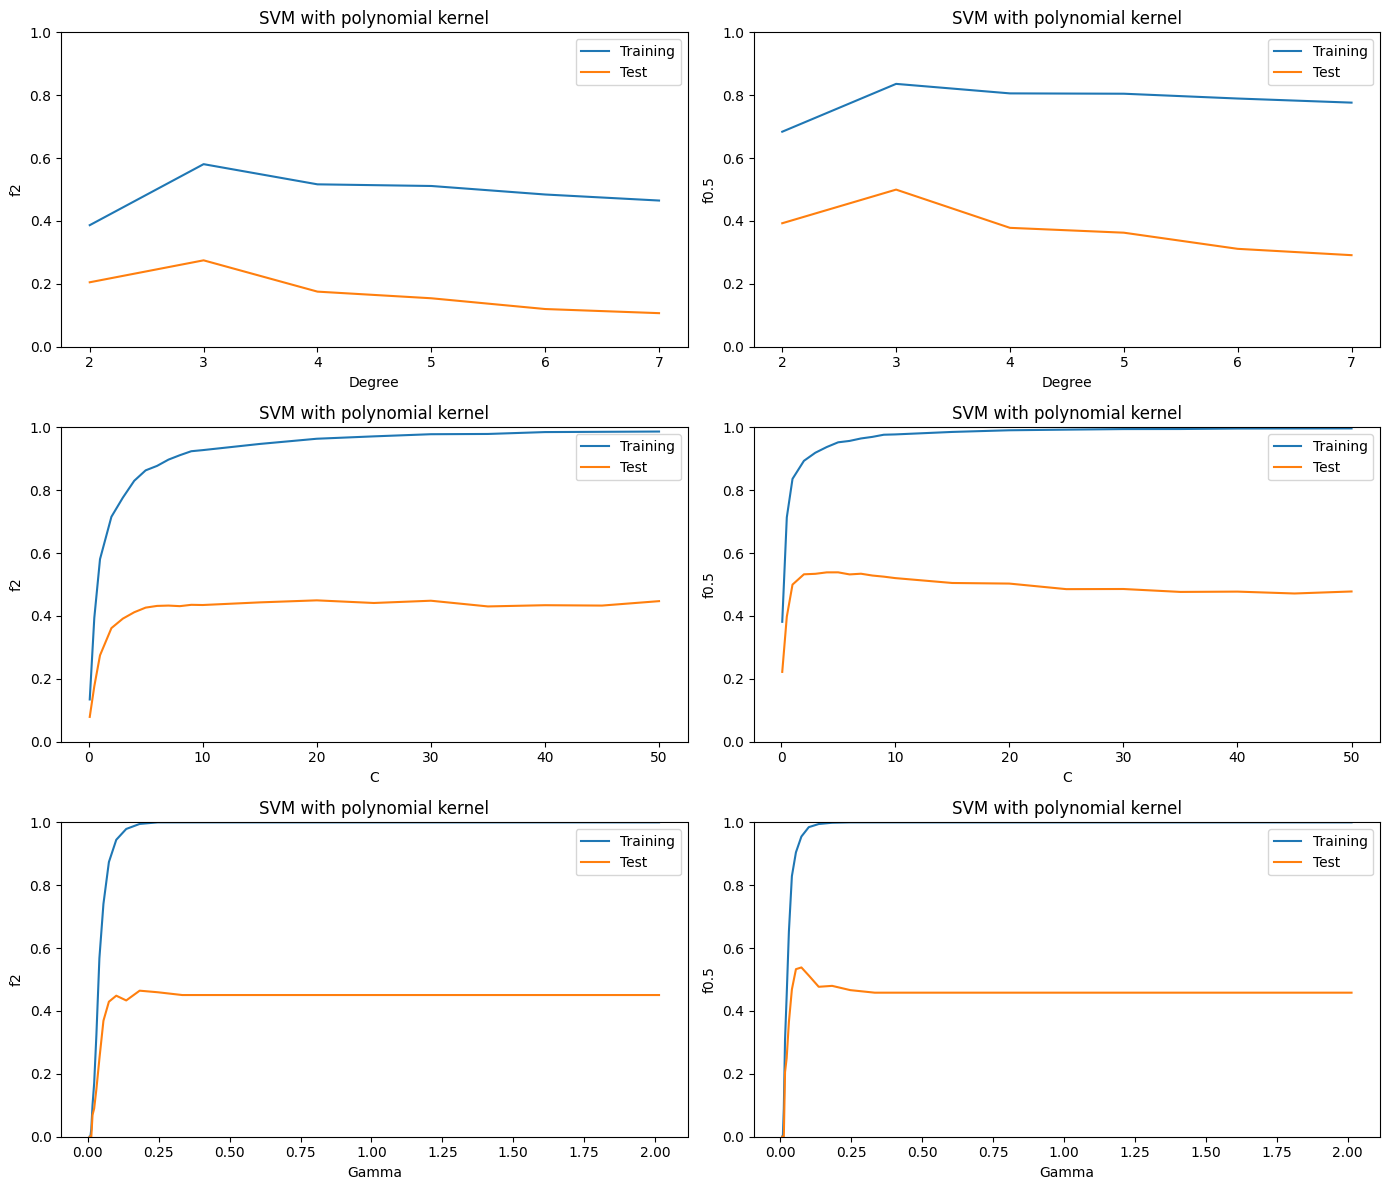

In [7]:
# SVM with polynomial kernel
# for score = f2 and f0.5
# hyperparameters gamma, C and degree, degree is the main one
def plot_poly_curve(gammas = 'scale', Cs = 1, degrees = 3, scoring = f2):

    num_splits = 5
    kfold = KFold(n_splits = 5, shuffle=True, random_state=0)

    if type(degrees) == np.ndarray:
        svm_poly = svm.SVC(kernel = 'poly', gamma = gammas, C = Cs)
        num_values = len(degrees)
        train_scores, valid_scores = validation_curve(svm_poly, X_train, y_train,
                                                  param_name="degree", param_range=degrees,
                                                  cv=kfold, scoring=scoring, n_jobs=-1)
        xlabel = 'Degree'; Xs = degrees; ylim = [0, 1]
    elif type(Cs) == np.ndarray:
        svm_poly = svm.SVC(kernel = 'poly', gamma = gammas, degree = degrees)
        num_values = len(Cs)
        train_scores, valid_scores = validation_curve(svm_poly, X_train, y_train,
                                                  param_name="C", param_range=Cs,
                                                  cv=kfold, scoring=scoring, n_jobs=-1)
        xlabel = 'C'; Xs = Cs; ylim = [0, 1]
    elif type(gammas) == np.ndarray:
        svm_poly = svm.SVC(kernel = 'poly', degree = degrees, C = Cs)
        num_values = len(gammas)
        train_scores, valid_scores = validation_curve(svm_poly, X_train, y_train,
                                                  param_name="gamma", param_range=gammas,
                                                  cv=kfold, scoring=scoring, n_jobs=-1)
        xlabel = 'Gamma'; Xs = gammas; ylim = [0, 1]
    else:
        raise TypeError

    plt.plot(Xs, train_scores.mean(axis=1), label = 'Training')
    plt.plot(Xs, valid_scores.mean(axis=1), label = 'Test')
    plt.xlabel(xlabel)
    plt.ylabel('f2' if scoring == f2 else 'f0.5')
    plt.ylim(ylim)
    plt.title('SVM with polynomial kernel')
    plt.legend()


plt.figure(figsize = (14, 12))
degrees = np.arange(2, 8, 1)
Cs = np.concatenate([[0.1, 0.5], np.arange(1, 10, 1), np.arange(10, 51, 5)])
gammas = np.exp(np.arange(-5, 1, 0.3))

plt.subplot(3, 2, 1); plot_poly_curve(degrees = degrees)
plt.subplot(3, 2, 2); plot_poly_curve(degrees = degrees, scoring = f05)
plt.subplot(3, 2, 3); plot_poly_curve(Cs = Cs)
plt.subplot(3, 2, 4); plot_poly_curve(Cs = Cs, scoring = f05)
plt.subplot(3, 2, 5); plot_poly_curve(gammas = gammas)
plt.subplot(3, 2, 6); plot_poly_curve(gammas = gammas, scoring = f05)
plt.tight_layout()
plt.show()

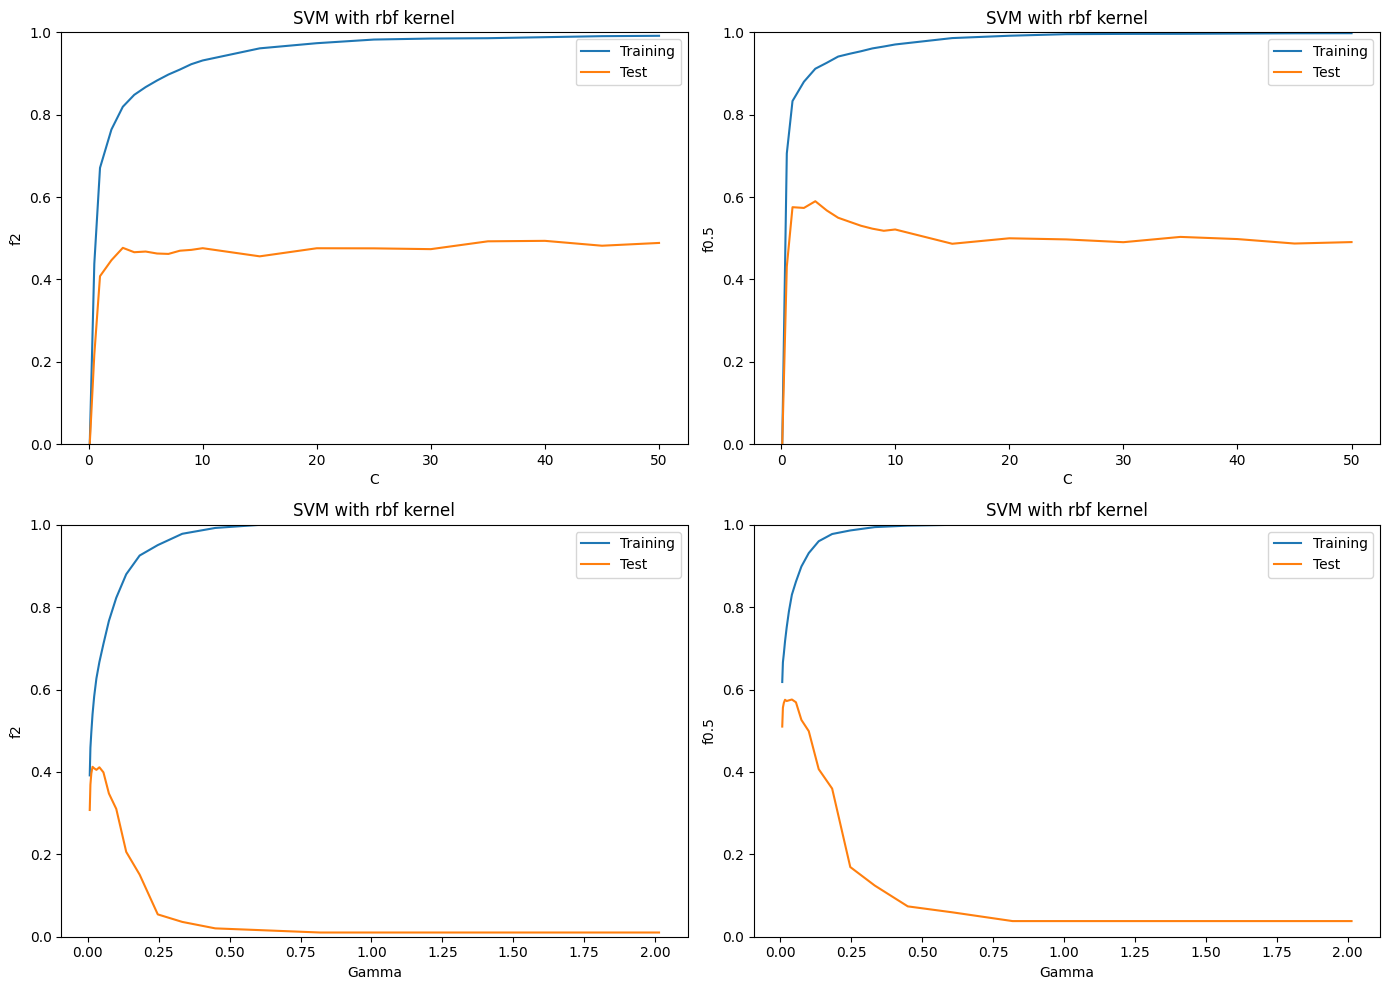

In [8]:
# The two functions can actually be integrated.
def plot_rbf_curve(gammas = 'scale', Cs = 1, scoring = f2):

    kfold = KFold(n_splits = 5, shuffle=True, random_state=0)

    if type(Cs) == np.ndarray:
        svm_rbf = svm.SVC(kernel = 'rbf', gamma = gammas)
        train_scores, valid_scores = validation_curve(svm_rbf, X_train, y_train,
                                                  param_name="C", param_range=Cs,
                                                  cv=kfold, scoring=scoring, n_jobs=-1)
        xlabel = 'C'; Xs = Cs; ylim = [0, 1]
    elif type(gammas) == np.ndarray:
        svm_rbf = svm.SVC(kernel = 'rbf', C = Cs)
        train_scores, valid_scores = validation_curve(svm_rbf, X_train, y_train,
                                                  param_name="gamma", param_range=gammas,
                                                  cv=kfold, scoring=scoring, n_jobs=-1)
        xlabel = 'Gamma'; Xs = gammas; ylim = [0, 1]
    else:
        raise TypeError

    plt.plot(Xs, train_scores.mean(axis=1), label = 'Training')
    plt.plot(Xs, valid_scores.mean(axis=1), label = 'Test')
    plt.xlabel(xlabel)
    plt.ylabel('f2' if scoring == f2 else 'f0.5')
    plt.ylim(ylim)
    plt.title('SVM with rbf kernel')
    plt.legend()


plt.figure(figsize = (14, 10))
plt.subplot(2, 2, 1); plot_rbf_curve(Cs = Cs)
plt.subplot(2, 2, 2); plot_rbf_curve(Cs = Cs, scoring = f05)
plt.subplot(2, 2, 3); plot_rbf_curve(gammas = gammas)
plt.subplot(2, 2, 4); plot_rbf_curve(gammas = gammas, scoring = f05)
plt.tight_layout()
plt.show()

The RBF kernel gives visibly more stable curves than polynomial across the hyperparameter range. Polynomial performance collapses at high degree (overfitting), while RBF is smooth in both C and gamma.

# Optimal hyperparameters
We use GridSearchCV to find the optimal hyperparameters. Gamma = `1/n_features` corresponds to the `'auto'` default in sklearn.

In [9]:
start = time.time()

param_grid = {'kernel' : ['poly', 'rbf', 'linear', 'sigmoid'],
              'C' : [0.01, 0.1, 0.5, 1, 10, 50, 100],
              'gamma' : [1/X_train.shape[1], 0.01, 0.1, 1],
              'degree' : [2, 3, 4, 5]}

scoring = {'Accuracy' : 'accuracy',
           'Precision' : 'precision',
           'recall' : 'recall',
           'f1' : 'f1',
           'f2' : f2,
           'f0.5' : f05}

svm_ = svm.SVC(random_state=0)
CV_svm = GridSearchCV(estimator = svm_, param_grid = param_grid, cv = 5,
                      scoring = scoring, refit = 'f2', n_jobs=-1)
CV_svm.fit(X_train, y_train)

print('time spent: ', time.time() - start)

time spent:  29.072736978530884


In [10]:
# a DataFrame to keep track of the results
params_ = CV_svm.cv_results_['params']
result = {k : [dic.get(k) for dic in params_] for k in ['kernel','C','gamma','degree']}
cln = ['kernel', 'C', 'gamma', 'degree']

for i in ['Accuracy', 'Precision', 'recall', 'f1', 'f2', 'f0.5']:
    result['mean_test_' + i] = CV_svm.cv_results_['mean_test_' + i]
    result['std_test_' + i] = CV_svm.cv_results_['std_test_' + i]
    cln.append('mean_test_' + i)

results = pd.DataFrame(result)

In [11]:
results.loc[results.kernel == 'linear', ['degree', 'gamma']] = np.nan
results.loc[results.kernel == 'rbf', 'degree'] = np.nan
results.loc[results.kernel == 'sigmoid', 'degree'] = np.nan

results.drop_duplicates(inplace = True)
results_sorted2 = results.sort_values('mean_test_f2', ascending = False)
display(results_sorted2.loc[:,cln].head(10))

,kernel,C,gamma,degree,mean_test_Accuracy,mean_test_Precision,mean_test_recall,mean_test_f1,mean_test_f2,mean_test_f0.5
327,sigmoid,50.0,0.01,NaN,0.75500,0.606839,0.533333,0.566294,0.545783,0.589503
389,rbf,100.0,0.01,NaN,0.74125,0.574717,0.533333,0.552777,0.540844,0.565606
156,poly,0.5,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
220,poly,1.0,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
92,poly,0.1,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
284,poly,10.0,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
412,poly,100.0,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
408,poly,100.0,0.10,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
344,poly,50.0,0.10,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283
348,poly,50.0,1.00,3.0,0.70250,0.503353,0.550000,0.524387,0.539132,0.511283


Top F2 scores are dominated by **RBF** and **linear** kernels with small gamma (0.01 to 1/n_features) and moderate C (1–10). Polynomial kernels do not make the top 10, consistent with the validation-curve observation that higher polynomial degrees overfit on this dataset.

In [12]:
results_sorted05 = results.sort_values('mean_test_f0.5', ascending = False)
display(results_sorted05.loc[:,cln].head(10))

,kernel,C,gamma,degree,mean_test_Accuracy,mean_test_Precision,mean_test_recall,mean_test_f1,mean_test_f2,mean_test_f0.5
261,rbf,10.0,0.010000,NaN,0.78500,0.697779,0.495833,0.578459,0.525706,0.644067
130,linear,0.5,NaN,NaN,0.77250,0.661434,0.500000,0.568515,0.525163,0.620499
258,linear,10.0,NaN,NaN,0.77125,0.656027,0.508333,0.571612,0.531668,0.619052
194,linear,1.0,NaN,NaN,0.77125,0.656213,0.504167,0.569276,0.528176,0.618110
322,linear,50.0,NaN,NaN,0.77000,0.652535,0.508333,0.570350,0.531243,0.616614
66,linear,0.1,NaN,NaN,0.77125,0.661521,0.487500,0.560225,0.514028,0.616491
386,linear,100.0,NaN,NaN,0.76875,0.649231,0.508333,0.569118,0.530822,0.614275
263,sigmoid,10.0,0.010000,NaN,0.76500,0.650030,0.495833,0.559245,0.518879,0.609154
197,rbf,1.0,0.010000,NaN,0.76250,0.709921,0.358333,0.475270,0.397346,0.592266
131,sigmoid,0.5,0.041667,NaN,0.75875,0.652984,0.437500,0.521242,0.467195,0.591825


The top F0.5 ranking is dominated by the same RBF + linear combinations, but with **smaller C** (stronger regularization → fewer, more confident positive predictions, which favors precision).

In [13]:
start = time.time()

C2 = np.concatenate([[0.5], np.arange(1, 10, 1), np.arange(10, 20, 2), np.arange(20, 51, 5)])

param_grid2 = {'C' : C2,
               'gamma' : np.append(np.arange(0.008, 0.051, 0.004), 1/X_train.shape[1])}

svm_2 = svm.SVC(kernel = 'rbf', random_state = 0)
CV_svm2 = GridSearchCV(estimator = svm_2, param_grid = param_grid2, cv = 5,
                       scoring = scoring, refit = 'f2', n_jobs=-1)
CV_svm2.fit(X_train, y_train)

print('time spent: ', time.time() - start)

time spent:  3.448988914489746


In [14]:
# a DataFrame to keep track of the results
params_2 = CV_svm2.cv_results_['params']
result2 = {k : [dic[k] for dic in params_2] for k in params_2[0]}

for i in ['Accuracy', 'Precision', 'recall', 'f1', 'f2', 'f0.5']:
    result2['mean_test_' + i] = CV_svm2.cv_results_['mean_test_' + i]
    result2['std_test_' + i] = CV_svm2.cv_results_['std_test_' + i]

results2 = pd.DataFrame(result2)
results2.loc[:, 'kernel'] = 'rbf'
results_all = pd.concat([results, results2], ignore_index=True)

In [15]:
# Sort all results:
results_all_sorted2 = results_all.sort_values('mean_test_f2', ascending = False)
results_all_sorted2.index = range(len(results_all_sorted2))
results_all_sorted05 = results_all.sort_values('mean_test_f0.5', ascending = False)
results_all_sorted05.index = range(len(results_all_sorted05))

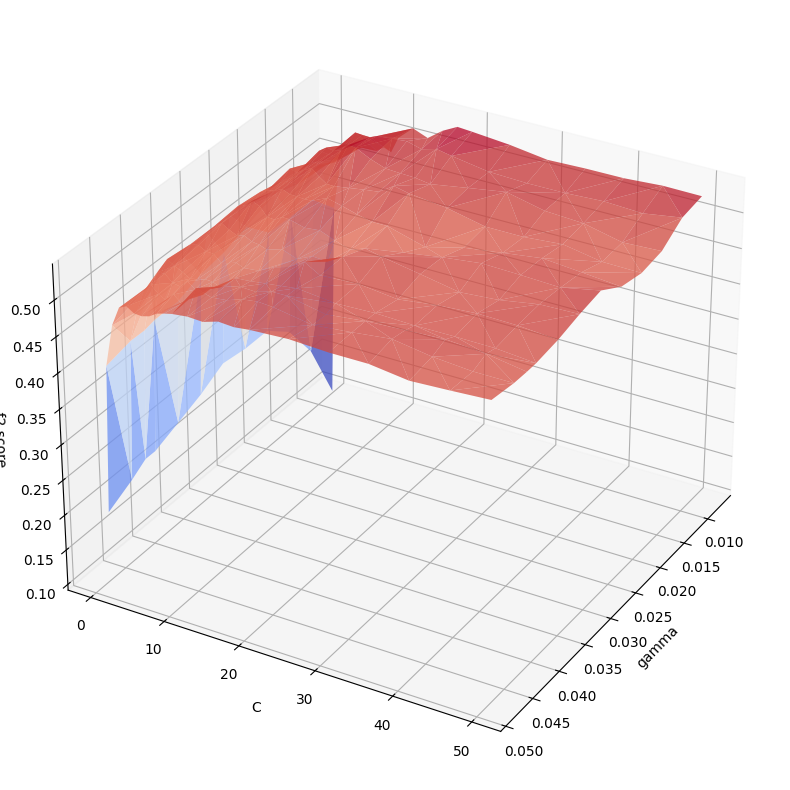

In [16]:
# Plot the surface for f2 score
plt.figure(figsize = (12, 10))
ax = plt.axes(projection='3d')
ax.plot_trisurf(results2.gamma, results2.C, results2.mean_test_f2,
                cmap = cm.coolwarm, alpha = 0.75)
ax.set_xlabel('gamma'); ax.set_ylabel('C'); ax.set_zlabel('f2 score')
ax.view_init(azim=30)
plt.show()

In [17]:
# We use the best one for f2:
print(results_all_sorted2.loc[0, ['C', 'gamma', 'kernel']])
svm_bestf2 = svm.SVC(C = results_all_sorted2.loc[0, 'C'],
                     gamma = results_all_sorted2.loc[0, 'gamma'],
                     kernel = results_all_sorted2.loc[0, 'kernel'],
                     random_state = 0)
svm_bestf2.fit(X_train, y_train)

y_train_pred = svm_bestf2.predict(X_train)
y_test_pred = svm_bestf2.predict(X_test)

conf_mat_train = confusion_matrix(y_train, y_train_pred)
conf_mat_test = confusion_matrix(y_test, y_test_pred)

f2_train = f2_scorer(y_train, y_train_pred)
f2_test = f2_scorer(y_test, y_test_pred)

print('Confusion matrix of training sample: \n', conf_mat_train)
print('Confusion matrix of test sample: \n', conf_mat_test)
print('f2 score of training sample: ', f2_train)
print('f2 score of test sample: ', f2_test)

C            50.0
gamma        0.01
kernel    sigmoid
Name: 0, dtype: object
Confusion matrix of training sample: 
 [[469  91]
 [125 115]]
Confusion matrix of test sample: 
 [[121  19]
 [ 32  28]]
f2 score of training sample:  0.49313893653516294
f2 score of test sample:  0.4878048780487805


In [18]:
# We use the best one for f0.5:
print(results_all_sorted05.loc[0, ['C', 'gamma', 'kernel']])
svm_bestf05 = svm.SVC(C = results_all_sorted05.loc[0, 'C'],
                      gamma = results_all_sorted05.loc[0, 'gamma'],
                      kernel = results_all_sorted05.loc[0, 'kernel'],
                      random_state = 0)
svm_bestf05.fit(X_train, y_train)

y_train_pred = svm_bestf05.predict(X_train)
y_test_pred = svm_bestf05.predict(X_test)

conf_mat_train = confusion_matrix(y_train, y_train_pred)
conf_mat_test = confusion_matrix(y_test, y_test_pred)

f05_train = f05_scorer(y_train, y_train_pred)
f05_test = f05_scorer(y_test, y_test_pred)

print('Confusion matrix of training sample: \n', conf_mat_train)
print('Confusion matrix of test sample: \n', conf_mat_test)
print('f0.5 score of training sample: ', f05_train)
print('f0.5 score of test sample: ', f05_test)

C          18.0
gamma     0.008
kernel      rbf
Name: 0, dtype: object
Confusion matrix of training sample: 
 [[532  28]
 [ 81 159]]
Confusion matrix of test sample: 
 [[126  14]
 [ 29  31]]
f0.5 score of training sample:  0.8046558704453441
f0.5 score of test sample:  0.6458333333333334


In [19]:
print('It takes ' + str(round(time.time() - begin, 4)) + ' seconds to run.')

It takes 143.0983 seconds to run.
